In [1]:
import gpflow 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm

import sys
sys.path.append("..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP
from atkernel import TransferKernel, TransferCoregion, LaggedRBF
from atlikelihood import TransferLikelihood

2025-11-12 14:42:57.304185: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 14:42:57.306994: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-12 14:42:57.364820: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-12 14:42:57.365811: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-12 14:42:58.386182: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
X = np.linspace(0, 300, 300).reshape(-1, 1)
k = gpflow.kernels.RBF(active_dims=[0], lengthscales=1, variance=10)
y  = np.random.multivariate_normal(np.zeros_like(X[:,0]), k(X)).reshape(-1, 1)

In [3]:
import tensorflow as tf
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF()

# now build the GP model as normal
lik = gpflow.likelihoods.Gaussian()

m = gpflow.models.GPR((X, y), kernel=k, likelihood=lik)
# fit the covariance function parameters
res = gpflow.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)
res

lml_src = m.log_marginal_likelihood(custom_X=X[:150], custom_Y=y[:150])
lml_tgt = m.log_marginal_likelihood(custom_X=X[150:], custom_Y=y[150:])
lml_tot = m.log_marginal_likelihood()
print("part 1, part 2, total:", lml_src, lml_tgt, lml_tot, lml_src+lml_tgt)
print(lml_src/lml_tot, lml_tgt/lml_tot)

part 1, part 2, total: tf.Tensor(-345.4581688665852, shape=(), dtype=float64) tf.Tensor(-336.79019213640527, shape=(), dtype=float64) tf.Tensor(-681.0888960967263, shape=(), dtype=float64) tf.Tensor(-682.2483610029905, shape=(), dtype=float64)
tf.Tensor(0.5072145073079039, shape=(), dtype=float64) tf.Tensor(0.4944878621080548, shape=(), dtype=float64)


/tmp/ipykernel_2504/1449595089.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL", start=start_date, end=end_date)['Close'].to_numpy()[:500]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2504/1449595089.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft = yf.download("MSFT", start=start_date, end=end_date)['Close'].to_numpy()[:500]
[*********************100%***********************]  1 of 1 completed


[  1   3  16  46  49  54  62  65  72  73  73  88 110 115 121 139 164 166
 172 179 187 187 196 203 211 221 239 256 258 259 297 328 330 347 354 362
 379 411 412 416 420 422 437 441 453 471 471 472 484 496]


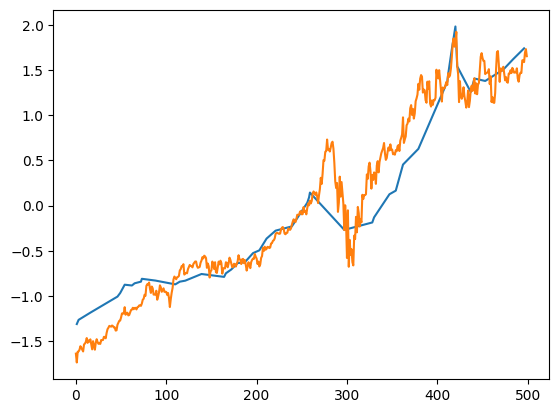

PearsonRResult(statistic=array([0.96749861]), pvalue=array([1.64311178e-299]))
1184.397170463643


In [4]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# here we load stock data from Yahoo Finance for the given dates
start_date = "2019-01-01"
end_date = "2024-01-01"

# retrive the data for AAPL and MSFT
aapl = yf.download("AAPL", start=start_date, end=end_date)['Close'].to_numpy()[:500]
msft = yf.download("MSFT", start=start_date, end=end_date)['Close'].to_numpy()[:500]

aapl_normed = (aapl - aapl.mean()) / aapl.std()

inds = np.sort(np.random.choice(np.arange(len(aapl)), int(len(aapl)/10)))
print(inds)
aapl_downs = aapl[inds]

# apply z normalization to the data for comparison
Y1 = (aapl_downs - aapl_downs.mean()) / aapl_downs.std()
Y2 = (msft - msft.mean()) / msft.std()
X1 = inds.reshape(-1, 1)
X2 = np.arange(len(Y2), dtype=float).reshape(-1, 1)
plt.plot(X1, Y1)
plt.plot(X2, Y2)
plt.show()

print(ss.pearsonr(aapl, msft))
print(dtw(aapl, msft))


In [5]:
# Augment the input with ones or zeros to indicate the required output dimension
X_augmented = np.vstack(
    (np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2))))
)

# Augment the Y data with ones or zeros that specify a likelihood from the list of likelihoods
Y_augmented = np.vstack(
    (np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2))))
)

def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, len(X2), len(X2))[:, None]
    (line,) = plt.plot(X2, Y2, ".", mew=2)
    (line,) = plt.plot(X2, aapl_normed, ".", mew=2, alpha=0.2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")
    (line,) = plt.plot(X1, Y1, ".", mew=2)
    #(line,) = plt.plot(np.arange(len(aapl_norm)), aapl, "x", mew=2, color="black")
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()



In [6]:
import tensorflow as tf
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF()

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg
kern = LaggedRBF(lag=2., source_length=len(aapl_downs))
#kern2 = TransferKernel(0.5, gpflow.kernels.RBF(), source_length=int(len(Y_augmented) - np.sum(Y_augmented[:,1])))

# This likelihood switches between Gaussian noise with different variances for each f_i:
# lik = gpflow.likelihoods.SwitchedLikelihood(likelihood_list=[gpflow.likelihoods.Gaussian(), gpflow.likelihoods.Gaussian()])
# now build the GP model as normal
lik = gpflow.likelihoods.Gaussian()

m = gpflow.models.GPR((X_augmented, Y_augmented), kernel=kern, likelihood=lik)
# fit the covariance function parameters
res = gpflow.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)
res
print(m.kernel.lag)

ValueError: Attempt to convert a value (<gpflow.kernels.stationaries.SquaredExponential object at 0x7f5e87d82650>) with an unsupported type (<class 'gpflow.kernels.stationaries.SquaredExponential'>) to a Tensor.

2025-11-12 14:12:44.785135: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-12 14:12:45.059260: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


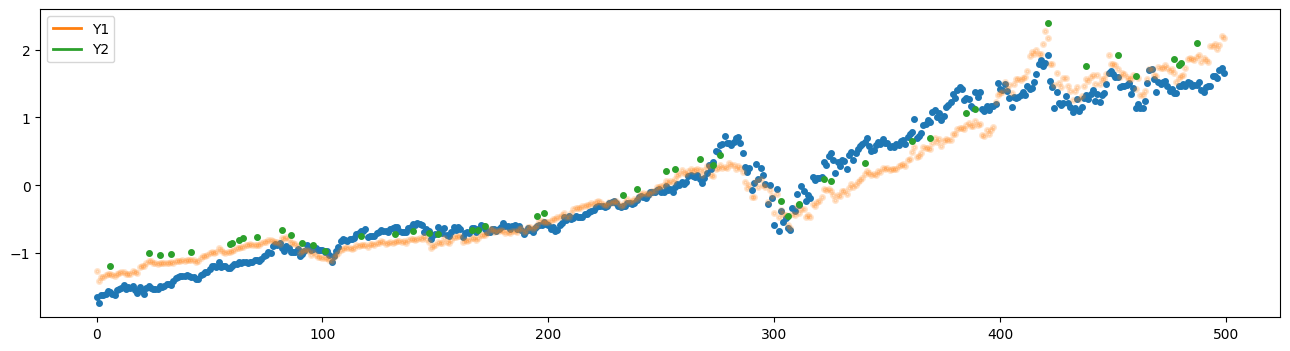

In [ ]:
plot(m)

In [ ]:
cov = m.kernel.kernels[1].output_covariance().numpy()
cov / cov.max()

AttributeError: 'LaggedRBF' object has no attribute 'kernels'

In [ ]:
unconstrained_transfer = AdaptiveTransferGPR(data_source=(X1, Y1), 
                            data_target=(X2, Y2), 
                            kernel=TransferCoregion(
                                lmb=-0.8, 
                                kernel=gpflow.kernels.RBF(), 
                                source_length=len(X1), use_lmb=False), 
                            )

res = gpflow.optimizers.Scipy().minimize(
    unconstrained_transfer.training_loss,
    unconstrained_transfer.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)

plot_gpr(unconstrained_transfer)

TypeError: in user code:

    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/gpflow/optimizers/scipy.py", line 192, in _tf_eval  *
        loss, grads = _compute_loss_and_gradients(
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/gpflow/optimizers/scipy.py", line 329, in _compute_loss_and_gradients  *
        loss = loss_closure()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/check_shapes/integration/tf.py", line 57, in wrapped_method  *
        return wrapped_function(self, *args, **kwargs)
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/check_shapes/decorator.py", line 121, in wrapped_function  *
        if not get_enable_check_shapes():
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/gpflow/models/training_mixins.py", line 64, in training_loss  *
        return self._training_loss()  # type: ignore[attr-defined]
    File "/home/janneke/miniforge3/envs/dev/lib/p